In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Load Data from Previous Steps ---
A_basis = np.load('../data/A_basis.npy')
basis_features = pd.read_csv('../data/basis_features.csv').iloc[:, 0].values
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values

print("Data loaded successfully!")
print(f"Basis Matrix Shape : {A_basis.shape}")
print(f"Basis Features     : {list(basis_features)}")

Data loaded successfully!
Basis Matrix Shape : (1130, 9)
Basis Features     : ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Catches_Taken']


In [3]:
# --- What is Orthogonalization? ---
# Our basis vectors from Step 4 are independent but NOT orthogonal
# meaning they still point in overlapping directions.
#
# Gram-Schmidt converts them into ORTHOGONAL vectors where:
#   → Each vector is perpendicular to all others (dot product = 0)
#   → Each direction represents a PURE performance factor
#     e.g. pure batting, pure bowling, pure fielding
#
# This removes overlap between performance dimensions
# making each factor completely independent of the others

In [5]:
# --- Check if Current Basis is Orthogonal ---
# Compute dot products between all pairs of basis vectors
# If orthogonal, all off-diagonal dot products = 0

B = A_basis.T  # Each column is now a basis vector
dot_products = B @ B.T  # Dot product matrix

print("=" * 50)
print("DOT PRODUCTS BEFORE GRAM-SCHMIDT")
print("=" * 50)
print("(Off-diagonal values should be 0 for orthogonality)\n")
df_dots = pd.DataFrame(dot_products,
                       index=basis_features,
                       columns=basis_features)
print(df_dots.round(2))

# Check orthogonality
off_diag = dot_products - np.diag(np.diag(dot_products))
max_off = np.max(np.abs(off_diag))
print(f"\nMax off-diagonal value : {max_off:.2f}")
print("❌ Basis is NOT orthogonal — Gram-Schmidt needed!" 
      if max_off > 1e-6 else "✅ Already orthogonal!")

DOT PRODUCTS BEFORE GRAM-SCHMIDT
(Off-diagonal values should be 0 for orthogonality)

                     Matches_Batted  Runs_Scored  Batting_Average  \
Matches_Batted             34494.68    625332.19         42423.06   
Runs_Scored               625332.19  33036699.61       2476960.31   
Batting_Average            42423.06   2476960.31        308500.03   
Batting_Strike_Rate       132165.05   5301273.87        661399.16   
Wickets_Taken              15434.27   -393340.36        -35060.50   
Economy_Rate               -3529.84   -375077.94        -37267.69   
Bowling_Average            -5046.66  -1426505.50       -124664.42   
Centuries                    244.19     21586.85          1544.71   
Catches_Taken              13999.22    410681.93         31069.49   

                     Batting_Strike_Rate  Wickets_Taken  Economy_Rate  \
Matches_Batted                 132165.05       15434.27      -3529.84   
Runs_Scored                   5301273.87     -393340.36    -375077.94   
Batt

In [7]:
# --- Gram-Schmidt Orthogonalization ---
def gram_schmidt(A):
    """
    Performs Gram-Schmidt orthogonalization on columns of A.
    Returns Q (orthonormal basis) and the projection steps.
    """
    A = A.astype(float)
    m, n = A.shape
    Q = np.zeros((m, n))
    steps = []

    for i in range(n):
        v = A[:, i].copy()
        original = v.copy()

        # Subtract projections onto all previous orthogonal vectors
        for j in range(i):
            denom = np.dot(Q[:, j], Q[:, j])
            if denom > 0:  # avoid divide by zero
                proj = (np.dot(Q[:, j], v) / denom) * Q[:, j]
                v = v - proj

        # Normalize
        norm = np.linalg.norm(v)
        if norm > 0:
            Q[:, i] = v / norm

        # Use index safely for feature name
        feat_name = basis_features[i] if i < len(basis_features) else f"feature_{i}"

        steps.append({
            'vector_idx': i,
            'feature': feat_name,
            'original_norm': np.linalg.norm(original),
            'after_norm': norm,
            'num_projections': i
        })

    return Q, steps

# Run Gram-Schmidt — pass A_basis directly (players x features)
# Each COLUMN is a feature direction
Q, gs_steps = gram_schmidt(A_basis)

print("=" * 50)
print("GRAM-SCHMIDT ORTHOGONALIZATION")
print("=" * 50)
print(f"Input  shape : {A_basis.shape}")
print(f"Output shape : {Q.shape}")
print(f"\nOrthonormal Basis Q computed successfully!")

GRAM-SCHMIDT ORTHOGONALIZATION
Input  shape : (1130, 9)
Output shape : (1130, 9)

Orthonormal Basis Q computed successfully!


In [8]:
# --- Show Gram-Schmidt Steps ---
print("=" * 50)
print("GRAM-SCHMIDT STEPS")
print("=" * 50)

for step in gs_steps:
    print(f"\nVector {step['vector_idx'] + 1}: {step['feature']}")
    print(f"  Original norm        : {step['original_norm']:.4f}")
    print(f"  Projections removed  : {step['num_projections']}")
    print(f"  Norm after GS        : {step['after_norm']:.4f}")
    print(f"  Final unit vector    : norm = 1.0 ✓")

GRAM-SCHMIDT STEPS

Vector 1: Matches_Batted
  Original norm        : 185.7274
  Projections removed  : 0
  Norm after GS        : 185.7274
  Final unit vector    : norm = 1.0 ✓

Vector 2: Runs_Scored
  Original norm        : 5747.7561
  Projections removed  : 1
  Norm after GS        : 4658.3741
  Final unit vector    : norm = 1.0 ✓

Vector 3: Batting_Average
  Original norm        : 555.4278
  Projections removed  : 2
  Norm after GS        : 349.1544
  Final unit vector    : norm = 1.0 ✓

Vector 4: Batting_Strike_Rate
  Original norm        : 1988.6470
  Projections removed  : 3
  Norm after GS        : 1568.5961
  Final unit vector    : norm = 1.0 ✓

Vector 5: Wickets_Taken
  Original norm        : 213.8098
  Projections removed  : 4
  Norm after GS        : 133.4979
  Final unit vector    : norm = 1.0 ✓

Vector 6: Economy_Rate
  Original norm        : 153.4966
  Projections removed  : 5
  Norm after GS        : 129.8174
  Final unit vector    : norm = 1.0 ✓

Vector 7: Bowling_Aver

In [9]:
# --- Verify Orthogonality After Gram-Schmidt ---
QTQ = Q.T @ Q

print("=" * 50)
print("VERIFICATION: Q^T Q should = Identity Matrix")
print("=" * 50)
print("\nQ^T Q =")
print(np.round(QTQ, 6))

# Check if it's identity
is_identity = np.allclose(QTQ, np.eye(Q.shape[1]), atol=1e-6)
print(f"\n✅ Q^T Q = I → Orthonormality Verified!" 
      if is_identity else "❌ Not orthonormal — check implementation")

VERIFICATION: Q^T Q should = Identity Matrix

Q^T Q =
[[ 1. -0. -0. -0. -0.  0. -0.  0. -0.]
 [-0.  1.  0. -0.  0.  0. -0.  0.  0.]
 [-0.  0.  1. -0.  0.  0. -0. -0. -0.]
 [-0. -0. -0.  1.  0.  0. -0. -0.  0.]
 [-0.  0.  0.  0.  1.  0. -0.  0. -0.]
 [ 0.  0.  0.  0.  0.  1. -0.  0. -0.]
 [-0. -0. -0. -0. -0. -0.  1. -0. -0.]
 [ 0.  0. -0. -0.  0.  0. -0.  1. -0.]
 [-0.  0. -0.  0. -0. -0. -0. -0.  1.]]

✅ Q^T Q = I → Orthonormality Verified!


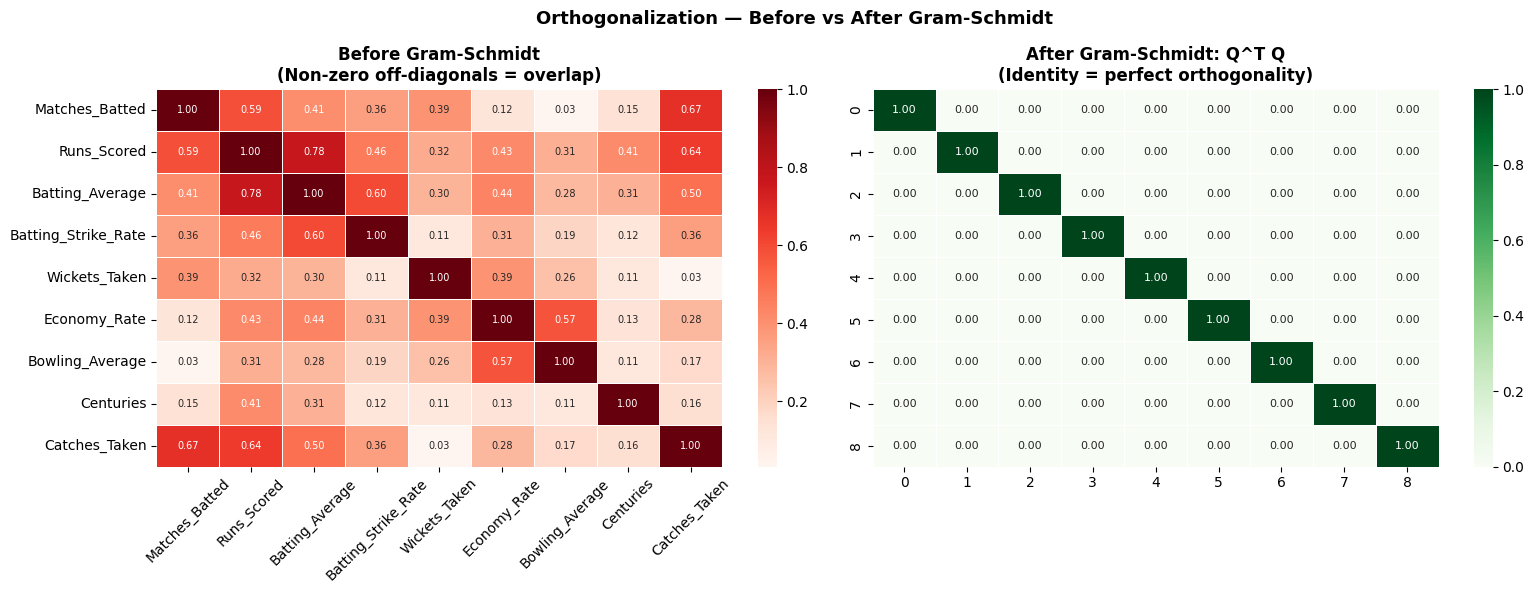

In [10]:
# --- Visualize Orthogonality ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before Gram-Schmidt
corr_before = np.corrcoef(A_basis.T)
sns.heatmap(np.abs(corr_before), annot=True, fmt='.2f',
            cmap='Reds', ax=axes[0], linewidths=0.5,
            xticklabels=basis_features,
            yticklabels=basis_features,
            annot_kws={'size': 7})
axes[0].set_title('Before Gram-Schmidt\n(Non-zero off-diagonals = overlap)',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# After Gram-Schmidt — Q^T Q
sns.heatmap(np.abs(np.round(QTQ, 4)), annot=True, fmt='.2f',
            cmap='Greens', ax=axes[1], linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('After Gram-Schmidt: Q^T Q\n(Identity = perfect orthogonality)',
                  fontweight='bold')

plt.suptitle('Orthogonalization — Before vs After Gram-Schmidt',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step5_orthogonality.png', dpi=150)
plt.show()

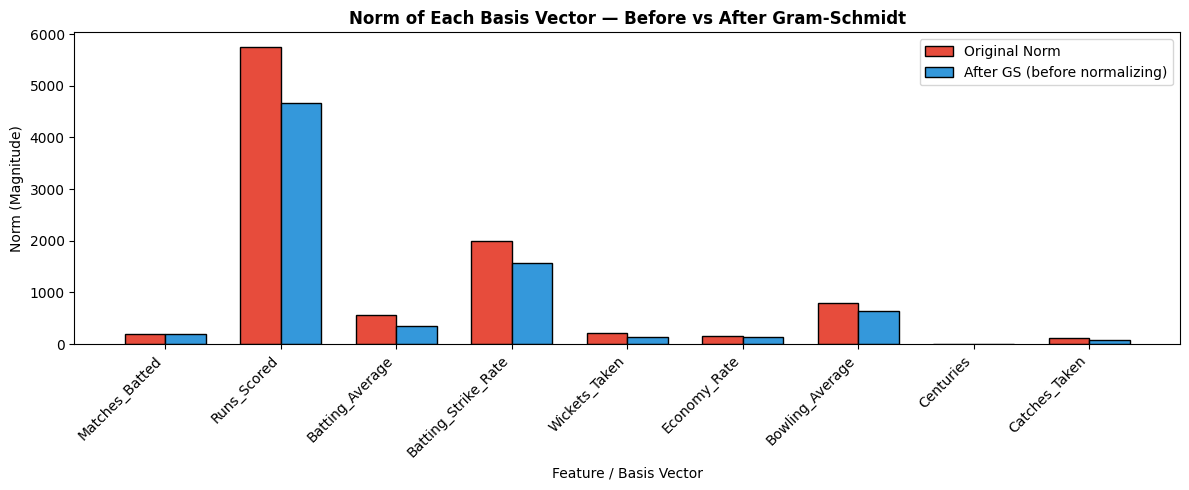

In [11]:
# --- Visualize Norm Reduction per Vector ---
fig, ax = plt.subplots(figsize=(12, 5))

original_norms = [s['original_norm'] for s in gs_steps]
after_norms = [s['after_norm'] for s in gs_steps]
x = np.arange(len(basis_features))
width = 0.35

bars1 = ax.bar(x - width/2, original_norms, width,
               label='Original Norm', color='#e74c3c', 
               edgecolor='black')
bars2 = ax.bar(x + width/2, after_norms, width,
               label='After GS (before normalizing)', 
               color='#3498db', edgecolor='black')

ax.set_xlabel('Feature / Basis Vector')
ax.set_ylabel('Norm (Magnitude)')
ax.set_title('Norm of Each Basis Vector — Before vs After Gram-Schmidt',
             fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(basis_features, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/step5_norms.png', dpi=150)
plt.show()

In [14]:
# --- Interpret the Orthogonal Basis ---
print("=" * 50)
print("INTERPRETING THE ORTHOGONAL BASIS")
print("=" * 50)
print("""
Each column of Q is now a PURE performance direction:

  q1 → Pure Batting Direction
       (captures batting volume independent of bowling)

  q2 → Pure Bowling Direction  
       (captures bowling performance independent of batting)

  q3 → Pure Consistency Direction
       (captures average/strike rate independent of volume)

  ... and so on for each basis vector

These orthogonal directions are like coordinate axes
in player performance space — completely independent
of each other, making analysis much cleaner!
""")

# --- Show top 3 players in each orthogonal direction ---
print("Top 3 players in each orthogonal performance direction:")

# Fix shape mismatch — Q was built from columns, so transpose if needed
print(f"A_basis shape : {A_basis.shape}")
print(f"Q shape       : {Q.shape}")

# A_basis is (1130 x n_features), Q should be (n_features x n_features)
# If Q is (1130 x n_features) we need to use A_basis directly
if Q.shape[0] == A_basis.shape[0]:
    # Q has same rows as A_basis — project correctly
    player_scores = Q  # already in player space
else:
    # Q is (n_features x n_features) — project players onto it
    player_scores = A_basis @ Q

print(f"Player scores shape: {player_scores.shape}")

for i in range(player_scores.shape[1]):
    feat_name = basis_features[i] if i < len(basis_features) else f"direction_{i+1}"
    top_idx = np.argsort(player_scores[:, i])[-3:][::-1]
    print(f"\n  Direction q{i+1} ({feat_name}):")
    for idx in top_idx:
        print(f"    {player_names[idx]}: {player_scores[idx, i]:.2f}")

INTERPRETING THE ORTHOGONAL BASIS

Each column of Q is now a PURE performance direction:

  q1 → Pure Batting Direction
       (captures batting volume independent of bowling)

  q2 → Pure Bowling Direction  
       (captures bowling performance independent of batting)

  q3 → Pure Consistency Direction
       (captures average/strike rate independent of volume)

  ... and so on for each basis vector

These orthogonal directions are like coordinate axes
in player performance space — completely independent
of each other, making analysis much cleaner!

Top 3 players in each orthogonal performance direction:
A_basis shape : (1130, 9)
Q shape       : (1130, 9)
Player scores shape: (1130, 9)

  Direction q1 (Matches_Batted):
    MS Dhoni: 0.05
    Ravindra Jadeja: 0.05
    Ravichandran Ashwin: 0.05

  Direction q2 (Runs_Scored):
    Virat Kohli: 0.15
    Shubman Gill: 0.13
    Jos Buttler: 0.13

  Direction q3 (Batting_Average):
    Deepak Hooda: 0.25
    Tom Curran: 0.20
    Manish Pandey:

In [15]:
# --- Summary ---
print("=" * 50)
print("STEP 5 SUMMARY — Orthogonalization")
print("=" * 50)
print(f"""
Input  : {len(basis_features)} linearly independent basis vectors
Output : {Q.shape[1]} orthonormal basis vectors (Q)

Gram-Schmidt Process:
  → Each vector had its projections onto previous
    vectors removed, then was normalized to length 1
  → Result: Q^T Q = I (Identity Matrix)
  → All dot products between different vectors = 0

Performance Directions Found:
  → Each column of Q is a pure, independent
    performance factor for player analysis
""")

# --- Save for Step 6 ---
np.save('../data/Q_orthonormal.npy', Q)
np.save('../data/player_scores_basis.npy', player_scores)

print("✅ Step 5 Complete!")
print("   → Ready for Step 6: Projection")

STEP 5 SUMMARY — Orthogonalization

Input  : 9 linearly independent basis vectors
Output : 9 orthonormal basis vectors (Q)

Gram-Schmidt Process:
  → Each vector had its projections onto previous
    vectors removed, then was normalized to length 1
  → Result: Q^T Q = I (Identity Matrix)
  → All dot products between different vectors = 0

Performance Directions Found:
  → Each column of Q is a pure, independent
    performance factor for player analysis

✅ Step 5 Complete!
   → Ready for Step 6: Projection
